[180000. 120000. 130000. 100000. 150000. 160000. 130000. 120000.  55000.
  95000. 150000. 135000.  40000. 100000. 130000.  55000.  50000.  45000.
  90000. 105000. 120000.  95000. 150000.  50000. 100000.  55000. 160000.
  40000. 130000. 100000.  45000. 110000.  45000. 150000. 110000.  35000.
 180000.  40000. 160000.  50000.  40000.  95000. 130000. 180000.  40000.
 160000. 120000.  40000.  40000.  40000. 140000.  90000. 130000. 130000.
 110000. 130000. 180000.  85000. 180000.  90000. 130000. 150000. 180000.
  50000.  50000.  40000.  45000. 110000.  40000.  35000. 100000. 110000.
  60000. 140000.  95000.]


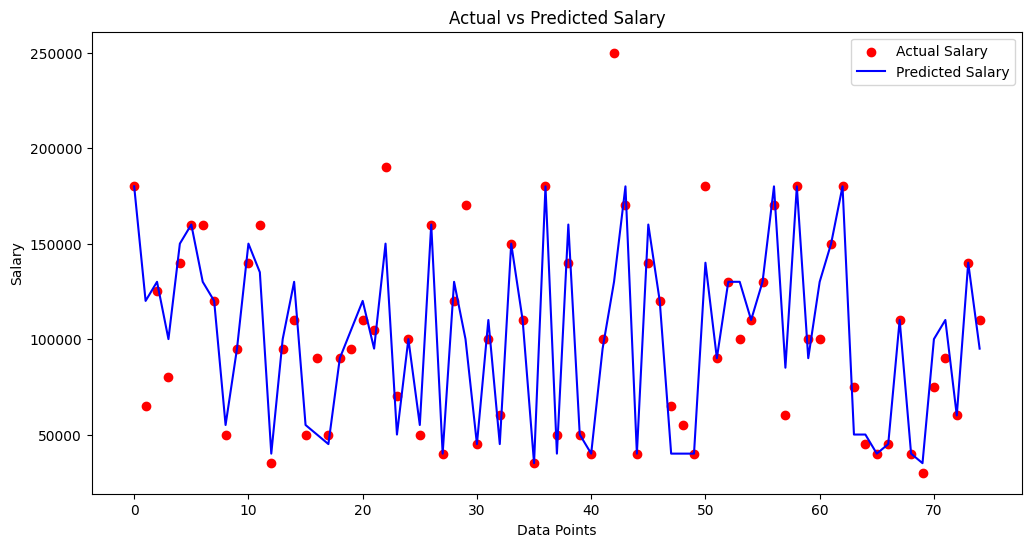

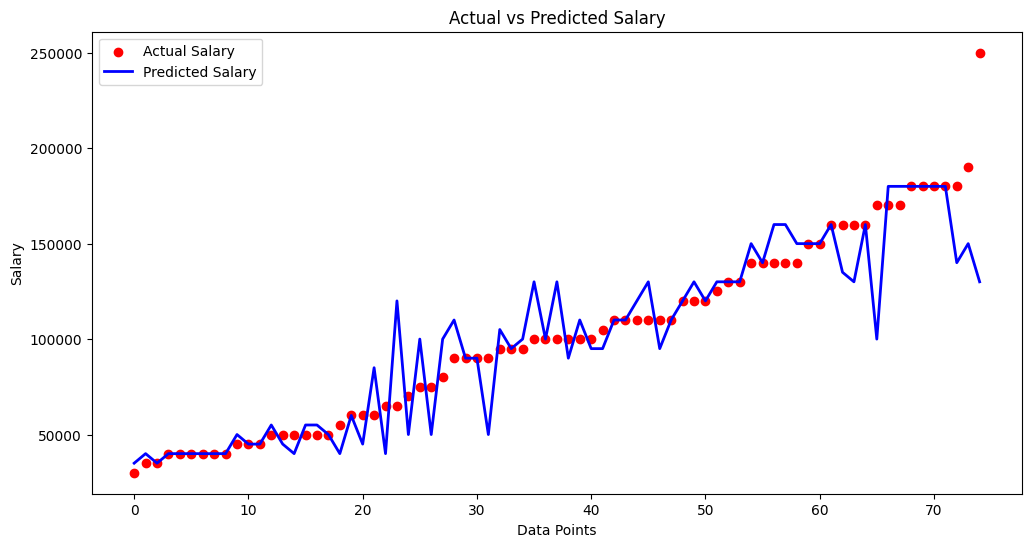

R2 Score: 0.7921517232174635


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

data = pd.read_csv('Salary Data.csv')

data = data.dropna()

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(sparse_output=False), [1, 2, 3])], remainder='passthrough'
)

X = np.array(ct.fit_transform(X))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(random_state=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred)
plt.figure(figsize=(12,6))

# Actual values as scatter
plt.scatter(
    range(len(y_test)),
    y_test,
    color='red',
    label='Actual Salary'
)

# Predicted values as line
plt.plot(
    range(len(y_pred)),
    y_pred,
    color='blue',
    label='Predicted Salary'
)

plt.xlabel("Data Points")
plt.ylabel("Salary")
plt.title("Actual vs Predicted Salary")

plt.legend()

plt.show()

plt.figure(figsize=(12,6))

# Sort test values
sorted_indices = y_test.argsort()

# Actual values
plt.scatter(
    range(len(y_test)),
    y_test[sorted_indices],
    color='red',
    label='Actual Salary'
)

# Predicted values
plt.plot(
    range(len(y_pred)),
    y_pred[sorted_indices],
    color='blue',
    linewidth=2,
    label='Predicted Salary'
)

plt.xlabel("Data Points")
plt.ylabel("Salary")
plt.title("Actual vs Predicted Salary")

plt.legend()

plt.show()

score = r2_score(y_test, y_pred)

print("R2 Score:", score)